# EDA & unsupervised learning

Clean data: `outputs/flight_delay_clean_2025_Q1.csv` 

get clean data by run 5243p4.ipynb file.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


## 1. Load cleaned dataset


In [34]:
df = pd.read_csv("outputs/flight_delay_clean_2025_Q1.csv")

display(df.head())
print("shape:", df.shape)
df.info()
df.describe(include="all")


,MONTH,DAY_OF_MONTH,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_DELAY,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,DEP_HOUR,FLIGHT_STATUS,IS_EXTREME_DELAY
0,1,1,9E,10397,15370,820,-6.0,938,-7.0,0.0,0,0,674.0,8,OnTime,0
1,1,1,9E,15370,10397,1018,-1.0,1315,-23.0,0.0,0,0,674.0,10,OnTime,0
2,1,1,9E,10397,13230,1110,-4.0,1303,-10.0,0.0,0,0,620.0,11,OnTime,0
3,1,1,9E,13230,10397,1350,-5.0,1608,-21.0,0.0,0,0,620.0,13,OnTime,0
4,1,1,9E,13230,10397,600,0.0,815,-16.0,0.0,0,0,620.0,6,OnTime,0


shape: (1823522, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1823522 entries, 0 to 1823521
Data columns (total 16 columns):
 #   Column             Dtype  
---  ------             -----  
 0   MONTH              int64  
 1   DAY_OF_MONTH       int64  
 2   OP_UNIQUE_CARRIER  object 
 3   ORIGIN_AIRPORT_ID  int64  
 4   DEST_AIRPORT_ID    int64  
 5   CRS_DEP_TIME       int64  
 6   DEP_DELAY          float64
 7   CRS_ARR_TIME       int64  
 8   ARR_DELAY          float64
 9   ARR_DEL15          float64
 10  CANCELLED          int64  
 11  DIVERTED           int64  
 12  DISTANCE           float64
 13  DEP_HOUR           int64  
 14  FLIGHT_STATUS      object 
 15  IS_EXTREME_DELAY   int64  
dtypes: float64(4), int64(10), object(2)
memory usage: 222.6+ MB


,MONTH,DAY_OF_MONTH,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_DELAY,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,DEP_HOUR,FLIGHT_STATUS,IS_EXTREME_DELAY
count,1.823522e+06,1.823522e+06,1823522,1.823522e+06,1.823522e+06,1.823522e+06,1.789778e+06,1.823522e+06,1.784397e+06,1.784397e+06,1.823522e+06,1.823522e+06,1.823522e+06,1.823522e+06,1823522,1.823522e+06
unique,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,WN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OnTime,NaN
freq,NaN,NaN,327938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1432429,NaN
mean,2.036149e+00,1.565369e+01,NaN,1.266832e+04,1.266825e+04,1.323197e+03,1.110660e+01,1.498154e+03,5.187444e+00,1.972476e-01,1.911795e-02,2.337784e-03,8.037759e+02,1.296274e+01,NaN,4.337760e-04
std,8.317617e-01,8.706285e+00,NaN,1.527161e+03,1.527191e+03,4.856362e+02,5.570506e+01,5.099309e+02,5.822466e+01,3.979209e-01,1.369396e-01,4.829410e-02,5.871022e+02,4.824269e+00,NaN,2.082278e-02
min,1.000000e+00,1.000000e+00,NaN,1.013500e+04,1.013500e+04,1.000000e+00,-5.600000e+01,1.000000e+00,-9.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.100000e+01,0.000000e+00,NaN,0.000000e+00
25%,1.000000e+00,8.000000e+00,NaN,1.129200e+04,1.129200e+04,9.100000e+02,-7.000000e+00,1.112000e+03,-1.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.720000e+02,9.000000e+00,NaN,0.000000e+00
50%,2.000000e+00,1.600000e+01,NaN,1.288900e+04,1.288900e+04,1.316000e+03,-3.000000e+00,1.520000e+03,-8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.500000e+02,1.300000e+01,NaN,0.000000e+00
75%,3.000000e+00,2.300000e+01,NaN,1.405700e+04,1.405700e+04,1.730000e+03,7.000000e+00,1.924000e+03,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.048000e+03,1.700000e+01,NaN,0.000000e+00


In [35]:
df["MONTH"].unique()

array([1, 2, 3])

In [36]:
df["MONTH"].value_counts().sort_index()

MONTH
1    599013
2    559577
3    664932
Name: count, dtype: int64

In [37]:
df["DAY_OF_MONTH"].nunique()

31

## 2. Basic dataset summary


In [38]:
summary = {
    "Number of rows": df.shape[0],
    "Number of columns": df.shape[1],
    "Number of carriers": df["OP_UNIQUE_CARRIER"].nunique(),
    "Number of origin airports": df["ORIGIN_AIRPORT_ID"].nunique(),
    "Number of destination airports": df["DEST_AIRPORT_ID"].nunique(),
    "Arrival delay rate (ARR_DEL15)": df["ARR_DEL15"].mean(),
    "Cancellation rate": df["CANCELLED"].mean(),
    "Diversion rate": df["DIVERTED"].mean(),
    "Extreme delay rate": df["IS_EXTREME_DELAY"].mean(),
}

display(pd.DataFrame(summary.items(), columns=["Metric", "Value"]))

missing_table = (
    pd.DataFrame({"missing_count": df.isna().sum(), "missing_rate": df.isna().mean()})
    .sort_values("missing_rate", ascending=False)
)
missing_table


,Metric,Value
0,Number of rows,1.823522e+06
1,Number of columns,1.600000e+01
2,Number of carriers,2.100000e+01
3,Number of origin airports,3.530000e+02
4,Number of destination airports,3.530000e+02
5,Arrival delay rate (ARR_DEL15),1.972476e-01
6,Cancellation rate,1.911795e-02
7,Diversion rate,2.337784e-03
8,Extreme delay rate,4.337760e-04


,missing_count,missing_rate
ARR_DELAY,39125,0.021456
ARR_DEL15,39125,0.021456
DEP_DELAY,33744,0.018505
MONTH,0,0.000000
DAY_OF_MONTH,0,0.000000
OP_UNIQUE_CARRIER,0,0.000000
ORIGIN_AIRPORT_ID,0,0.000000
DEST_AIRPORT_ID,0,0.000000
CRS_DEP_TIME,0,0.000000
CRS_ARR_TIME,0,0.000000


## 3. EDA: target distribution (ARR_DEL15)

Binary supervised target: 1 if arrival delay ≥ 15 minutes (per carrier reporting definitions in BTS).


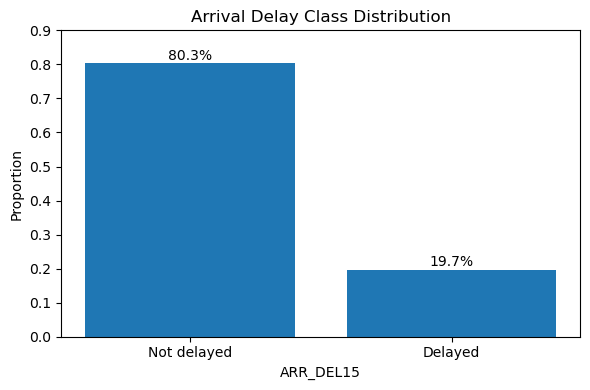

ARR_DEL15
0.0    0.802752
1.0    0.197248
Name: proportion, dtype: float64

In [39]:
delay_counts = df["ARR_DEL15"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(["Not delayed", "Delayed"], delay_counts.values)

plt.ylabel("Proportion")
plt.xlabel("ARR_DEL15")
plt.title("Arrival Delay Class Distribution")

for bar, value in zip(bars, delay_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.1%}",
        ha="center"
    )

plt.ylim(0, 0.9)
plt.tight_layout()
plt.show()
delay_counts

This figure shows the class distribution of our target variable, ARR_DEL15. Around 80% of flights were not delayed by 15 minutes or more, while about 20% were delayed. This means the target variable is somewhat imbalanced. Therefore, in the supervised modeling part, accuracy alone may not be enough, because a model could get high accuracy by predicting most flights as not delayed. We should also consider metrics such as precision, recall, F1-score, and ROC-AUC.

## 4. EDA: arrival delay in minutes (ARR_DELAY)


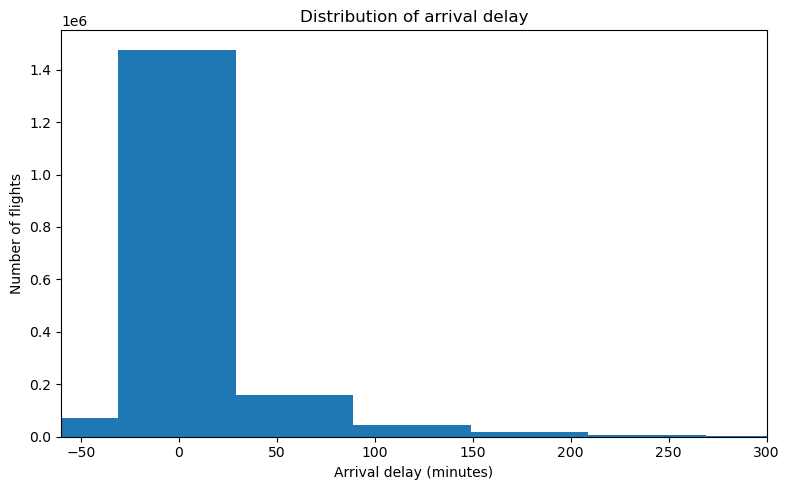

count    1.784397e+06
mean     5.187444e+00
std      5.822466e+01
min     -9.100000e+01
1%      -4.000000e+01
5%      -3.000000e+01
25%     -1.700000e+01
50%     -8.000000e+00
75%      8.000000e+00
95%      8.100000e+01
99%      2.140000e+02
max      5.907000e+03
Name: ARR_DELAY, dtype: float64

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(df["ARR_DELAY"].dropna(), bins=100)
plt.xlim(-60, 300)
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of arrival delay")
plt.tight_layout()
plt.show()

df["ARR_DELAY"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])


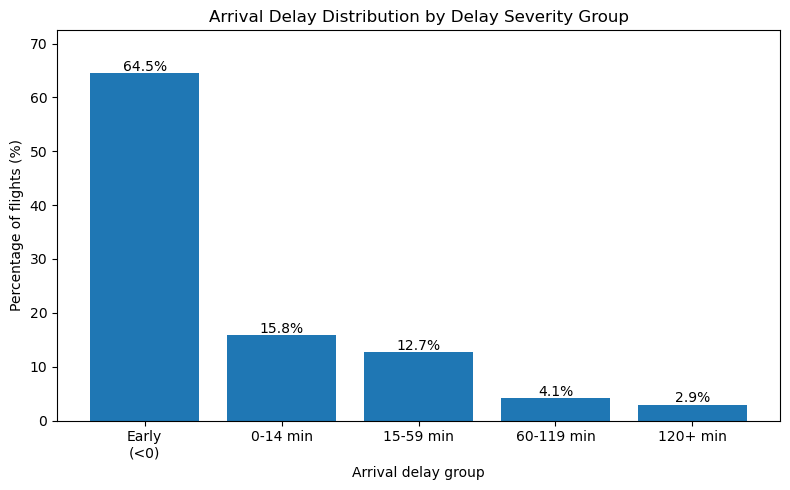

ARR_DELAY
Early\n(<0)    64.469622
0-14 min       15.805619
15-59 min      12.665287
60-119 min      4.141175
120+ min        2.918297
Name: proportion, dtype: float64

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

arr_delay = df["ARR_DELAY"].dropna()

delay_bins = [-np.inf, 0, 15, 60, 120, np.inf]
delay_labels = [
    "Early\n(<0)",
    "0-14 min",
    "15-59 min",
    "60-119 min",
    "120+ min"
]

delay_group = pd.cut(arr_delay, bins=delay_bins, labels=delay_labels, right=False)

delay_group_pct = delay_group.value_counts(normalize=True).reindex(delay_labels) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(delay_group_pct.index, delay_group_pct.values)

plt.ylabel("Percentage of flights (%)")
plt.xlabel("Arrival delay group")
plt.title("Arrival Delay Distribution by Delay Severity Group")

for bar, value in zip(bars, delay_group_pct.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, delay_group_pct.max() + 8)
plt.tight_layout()
plt.show()

delay_group_pct

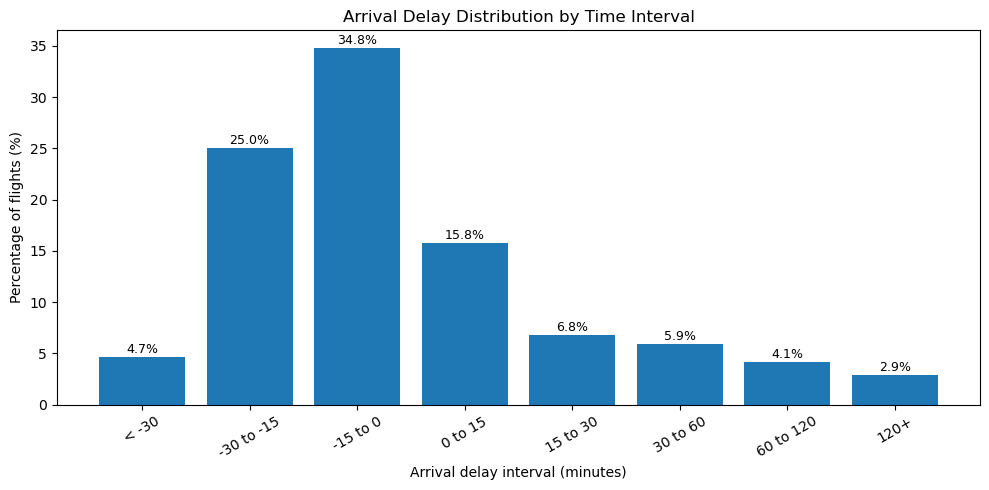

ARR_DELAY
< -30          4.650591
-30 to -15    25.036917
-15 to 0      34.782114
0 to 15       15.805619
15 to 30       6.763405
30 to 60       5.901882
60 to 120      4.141175
120+           2.918297
Name: proportion, dtype: float64

In [42]:
delay_bins = [-np.inf, -30, -15, 0, 15, 30, 60, 120, np.inf]
delay_labels = [
    "< -30",
    "-30 to -15",
    "-15 to 0",
    "0 to 15",
    "15 to 30",
    "30 to 60",
    "60 to 120",
    "120+"
]

delay_group = pd.cut(arr_delay, bins=delay_bins, labels=delay_labels, right=False)
delay_group_pct = delay_group.value_counts(normalize=True).reindex(delay_labels) * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(delay_group_pct.index, delay_group_pct.values)

plt.ylabel("Percentage of flights (%)")
plt.xlabel("Arrival delay interval (minutes)")
plt.title("Arrival Delay Distribution by Time Interval")
plt.xticks(rotation=30)

for bar, value in zip(bars, delay_group_pct.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

delay_group_pct

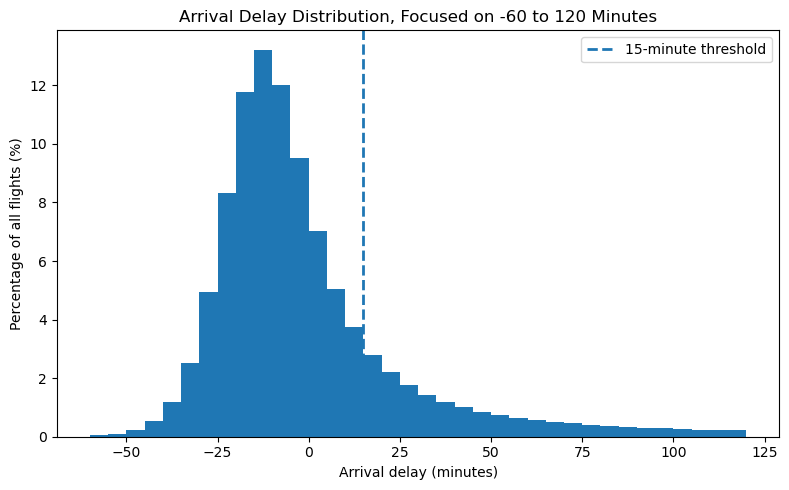

In [43]:
arr_delay = df["ARR_DELAY"].dropna()

central_delay = arr_delay[(arr_delay >= -60) & (arr_delay <= 120)]

weights = np.ones(len(central_delay)) / len(arr_delay) * 100

plt.figure(figsize=(8, 5))
plt.hist(
    central_delay,
    bins=np.arange(-60, 125, 5),
    weights=weights
)

plt.axvline(15, linestyle="--", linewidth=2, label="15-minute threshold")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Percentage of all flights (%)")
plt.title("Arrival Delay Distribution, Focused on -60 to 120 Minutes")
plt.legend()
plt.tight_layout()
plt.show()

This histogram shows the distribution of arrival delay in minutes. Negative values mean the flight arrived earlier than scheduled, while positive values indicate delay. Most flights arrive close to the scheduled time, and many even arrive early. However, the distribution is strongly right-skewed, meaning that a small number of flights experience very long delays. This long-tail pattern explains why the average arrival delay can be positive even though the median arrival delay is negative.

The arrival delay distribution is right-skewed. Most flights arrive early or close to the scheduled arrival time, with the highest concentration between about -20 and 0 minutes. However, the right tail is much longer than the left tail because some flights experience long positive delays. This is also supported by the summary statistics: the median arrival delay is negative, but the mean arrival delay is positive, meaning that extreme delays pull the average upward.

## 5. EDA: delay rate by carrier


Arrival delay rates vary substantially across carriers. The highest-delay carriers have delay rates close to 25–29%, while the lowest-delay carriers are around 16–17%. This suggests that carrier identity may capture operational differences such as route network, scheduling practices, turnaround time, and airport exposure.

Because delay rates differ across carriers, OP_UNIQUE_CARRIER should be considered as a categorical feature in the supervised models, after appropriate encoding such as one-hot encoding.

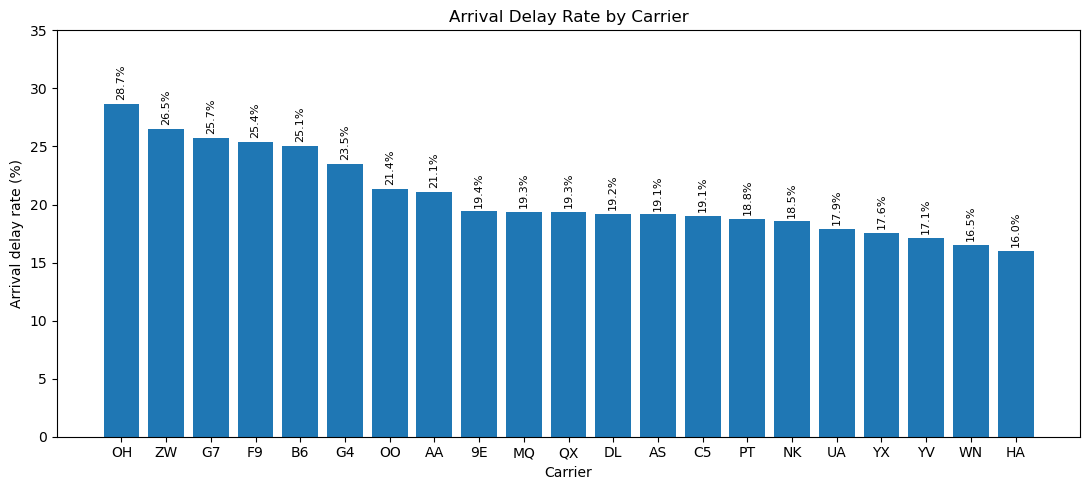

In [44]:
carrier_delay = (
    df.groupby("OP_UNIQUE_CARRIER")
    .agg(
        flight_count=("ARR_DEL15", "count"),
        delay_rate=("ARR_DEL15", "mean"),
        avg_arr_delay=("ARR_DELAY", "mean")
    )
    .sort_values("delay_rate", ascending=False)
)

plt.figure(figsize=(11, 5))
bars = plt.bar(carrier_delay.index, carrier_delay["delay_rate"] * 100)

plt.ylabel("Arrival delay rate (%)")
plt.xlabel("Carrier")
plt.title("Arrival Delay Rate by Carrier")

for bar, value in zip(bars, carrier_delay["delay_rate"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.ylim(0, 35)
plt.tight_layout()
plt.show()

Arrival delay rates differ across carriers. In this dataset, the highest observed delay rate is for carrier OH at about 28.7%, while the lowest is for carrier HA at about 16.0%. This difference suggests that carrier identity may capture meaningful operational variation related to arrival delay risk. However, this result should be interpreted as an association rather than a causal ranking of airline performance, since carriers may operate different route networks and airport combinations.

## 6. EDA: delay rate by scheduled departure hour


,flight_count,delay_rate,avg_arr_delay
DEP_HOUR,,,
0,2050,0.120488,-5.129756
1,837,0.145759,-2.505376
2,269,0.182156,-1.758364
3,213,0.131455,2.159624
4,136,0.125000,-4.647059
5,49260,0.108445,-1.373589
6,121806,0.115856,-1.833580
7,122949,0.134958,-0.793793
8,124127,0.151144,-0.072547


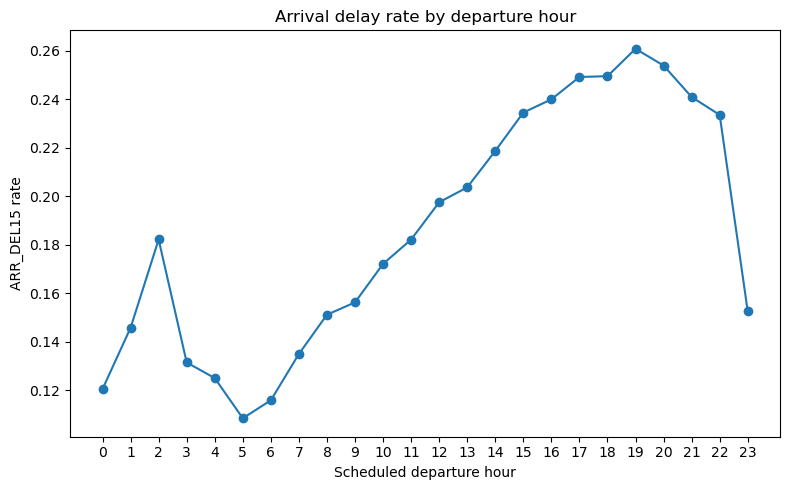

In [45]:
hour_delay = (
    df.groupby("DEP_HOUR")
    .agg(
        flight_count=("ARR_DEL15", "count"),
        delay_rate=("ARR_DEL15", "mean"),
        avg_arr_delay=("ARR_DELAY", "mean"),
    )
)

display(hour_delay)

plt.figure(figsize=(8, 5))
plt.plot(hour_delay.index, hour_delay["delay_rate"], marker="o")
plt.xlabel("Scheduled departure hour")
plt.ylabel("ARR_DEL15 rate")
plt.title("Arrival delay rate by departure hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


Arrival delay rates vary strongly by scheduled departure hour. Early morning flights have the lowest delay rates, while delay rates increase steadily from late morning through the evening. The highest delay rate occurs around 19:00, where approximately 26% of flights arrive at least 15 minutes late. This pattern suggests that delays may accumulate throughout the day due to aircraft rotation, crew scheduling, airport congestion, and earlier disruptions. Therefore, DEP_HOUR is an important time-based feature for later supervised modeling. The late-night decrease should be interpreted carefully because the number and type of flights differ from daytime hours.

## 7. EDA: delay rate by distance group


Rows without a distance bucket: 0


,flight_count,delay_rate,avg_arr_delay
DISTANCE_GROUP,,,
Short,656136,0.193515,6.053682
Medium,624357,0.200815,5.676163
Long,405363,0.202946,4.457777
Very long,98541,0.176059,-0.675343


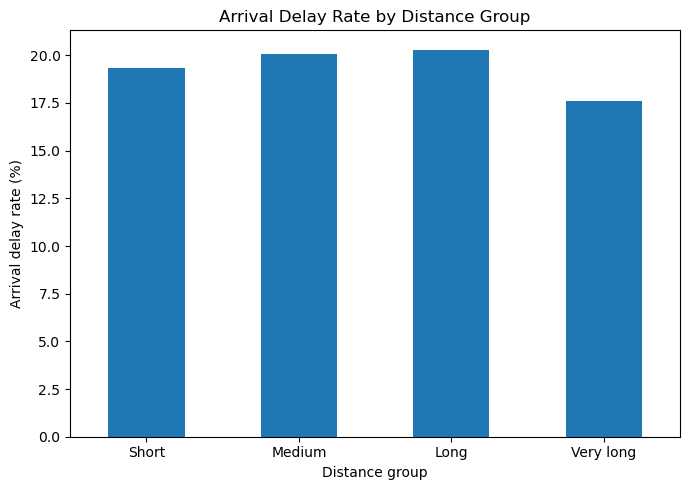

In [46]:
df["DISTANCE_GROUP"] = pd.cut(
    df["DISTANCE"],
    bins=[0, 500, 1000, 2000, np.inf],
    labels=["Short", "Medium", "Long", "Very long"],
    include_lowest=True
)

n_uncut = int(df["DISTANCE_GROUP"].isna().sum())
print("Rows without a distance bucket:", n_uncut)

distance_delay = (
    df.groupby("DISTANCE_GROUP", observed=True)
    .agg(
        flight_count=("ARR_DEL15", "count"),
        delay_rate=("ARR_DEL15", "mean"),
        avg_arr_delay=("ARR_DELAY", "mean"),
    )
)

display(distance_delay)

plt.figure(figsize=(7, 5))
(distance_delay["delay_rate"] * 100).plot(kind="bar")
plt.ylabel("Arrival delay rate (%)")
plt.xlabel("Distance group")
plt.title("Arrival Delay Rate by Distance Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Delay rates are relatively close across short, medium, and long flights, staying around 19–20%. Very long flights show a slightly lower delay rate and lower average arrival delay, which may indicate that longer routes have more schedule buffer or more opportunity to recover time during the flight. However, distance alone does not appear to create as large a difference as carrier or departure hour.

## 8. EDA: flight status distribution(not importtant because pretty similar to first plot) may not include in the report and slides


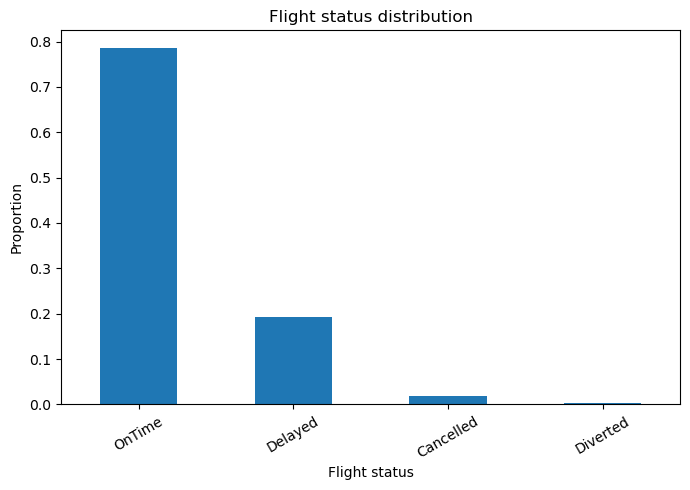

FLIGHT_STATUS
OnTime       0.785529
Delayed      0.193015
Cancelled    0.019118
Diverted     0.002338
Name: proportion, dtype: float64

In [47]:
status_dist = df["FLIGHT_STATUS"].value_counts(normalize=True)

plt.figure(figsize=(7, 5))
status_dist.plot(kind="bar")
plt.ylabel("Proportion")
plt.xlabel("Flight status")
plt.title("Flight status distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

status_dist


The flight status distribution shows that most flights were on time, while delayed flights account for about one-fifth of the data. Cancelled and diverted flights are relatively rare, but they are important because they help explain missing values in arrival-related variables. Since FLIGHT_STATUS is derived from flight outcomes, it is used only for descriptive EDA and should not be used as an independent predictor of ARR_DEL15.

## 9. EDA: origin airports with highest delay rates

Restrict to airports with enough flights so rates are stable (e.g. ≥ 1000 departures in Q1).

IATA codes come from outputs/airportid1.csv – airportid3.csv: each row maps ORIGIN_AIRPORT_ID and ORIGIN; we concatenate the three months and drop duplicate IDs to build one lookup table.


,ORIGIN_AIRPORT_ID,flight_count,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate,ORIGIN,origin_label
20,10372,2779,0.352645,23.956819,33.423504,0.080698,0.003953,652.594862,12.613966,0.002635,ASE,ASE (10372)
339,15380,1036,0.328185,17.451737,16.882466,0.006699,0.001914,392.049761,11.658373,0.001914,TVC,TVC (15380)
172,12441,1709,0.297835,17.586308,23.216028,0.014917,0.004590,821.720597,12.552496,0.002869,JAC,JAC (12441)
128,11823,1821,0.291598,16.644701,18.119035,0.015659,0.001080,492.725702,12.131210,0.001620,FWA,FWA (11823)
115,11624,2343,0.285105,17.798122,21.848229,0.017805,0.012008,814.392547,13.585093,0.001242,EYW,EYW (11624)
105,11503,2088,0.284004,13.180077,20.617143,0.010839,0.005184,849.781810,12.260603,0.002356,EGE,EGE (11503)
147,12094,1200,0.275833,15.195000,23.094371,0.024272,0.004854,758.537217,12.884304,0.002427,HDN,HDN (12094)
88,11278,33943,0.268627,12.882951,18.219679,0.062083,0.001765,647.624717,13.280297,0.000386,DCA,DCA (11278)
256,14108,1219,0.263331,18.299426,21.664210,0.022436,0.000801,524.733974,11.937500,0.004808,PIA,PIA (14108)
331,15096,3606,0.261509,13.232668,15.984790,0.029024,0.001881,507.492072,11.091642,0.001881,SYR,SYR (15096)


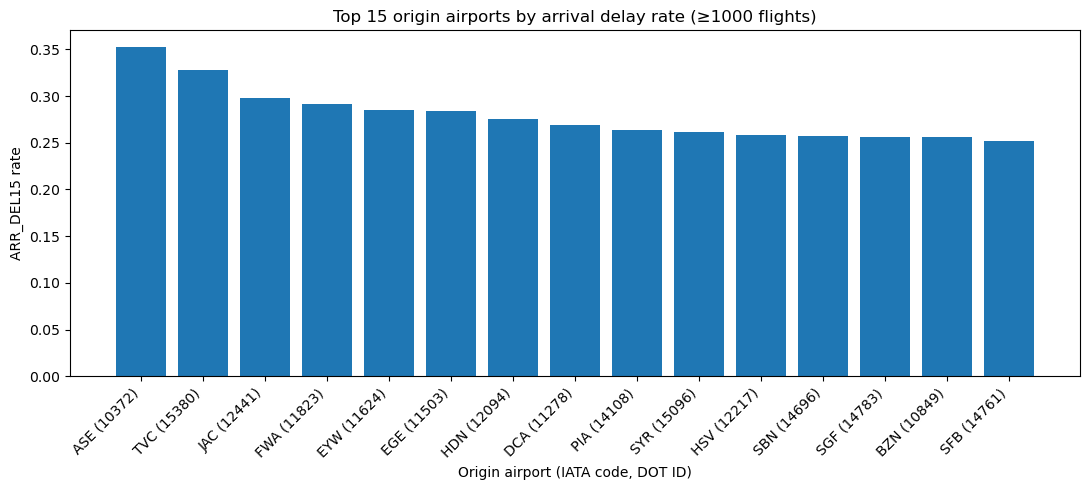

In [48]:
# DOT airport ID → IATA (ORIGIN): combine Jan–Mar extracts, keep one row per ID
_origin_parts = []
for _path in (
    "outputs/airportid1.csv",
    "outputs/airportid2.csv",
    "outputs/airportid3.csv",
):
    _origin_parts.append(pd.read_csv(_path, usecols=["ORIGIN_AIRPORT_ID", "ORIGIN"]))
_origin_lookup = pd.concat(_origin_parts, ignore_index=True).drop_duplicates(
    subset=["ORIGIN_AIRPORT_ID"]
)

airport_summary = (
    df.groupby("ORIGIN_AIRPORT_ID")
    .agg(
        flight_count=("ARR_DEL15", "count"),
        delay_rate=("ARR_DEL15", "mean"),
        avg_arr_delay=("ARR_DELAY", "mean"),
        avg_dep_delay=("DEP_DELAY", "mean"),
        cancellation_rate=("CANCELLED", "mean"),
        diversion_rate=("DIVERTED", "mean"),
        avg_distance=("DISTANCE", "mean"),
        avg_dep_hour=("DEP_HOUR", "mean"),
        extreme_delay_rate=("IS_EXTREME_DELAY", "mean"),
    )
    .reset_index()
)

airport_summary = airport_summary.merge(
    _origin_lookup, on="ORIGIN_AIRPORT_ID", how="left"
)

large_airports = airport_summary[airport_summary["flight_count"] >= 1000].copy()
top_airports = large_airports.sort_values("delay_rate", ascending=False).head(15)

top_airports["origin_label"] = np.where(
    top_airports["ORIGIN"].notna(),
    top_airports["ORIGIN"].astype(str)
    + " ("
    + top_airports["ORIGIN_AIRPORT_ID"].astype(str)
    + ")",
    top_airports["ORIGIN_AIRPORT_ID"].astype(str),
)

display(top_airports)

plt.figure(figsize=(11, 5))
plt.bar(np.arange(len(top_airports)), top_airports["delay_rate"])
plt.xticks(
    np.arange(len(top_airports)),
    top_airports["origin_label"],
    rotation=45,
    ha="right",
)
plt.ylabel("ARR_DEL15 rate")
plt.xlabel("Origin airport (IATA code, DOT ID)")
plt.title("Top 15 origin airports by arrival delay rate (≥1000 flights)")
plt.tight_layout()
plt.show()


This figure shows the top 15 origin airports with the highest arrival delay rates, after restricting the analysis to airports with at least 1,000 flights in the quarter. This filter helps avoid unstable rates from very small airports. The top airport has an arrival delay rate above 35%, compared with the overall delay rate of about 19.7%. This suggests that delay risk has an airport-level pattern, not only a flight-level pattern.

This finding motivates the airport-level clustering analysis. Since delay patterns differ across origin airports, we use unsupervised learning to group airports with similar operational profiles.

## 10. Correlation heatmap (numeric columns)

`ARR_DELAY` is mechanically related to `ARR_DEL15`; report that correlation reflects the definition of the label, not a legitimate predictive feature.


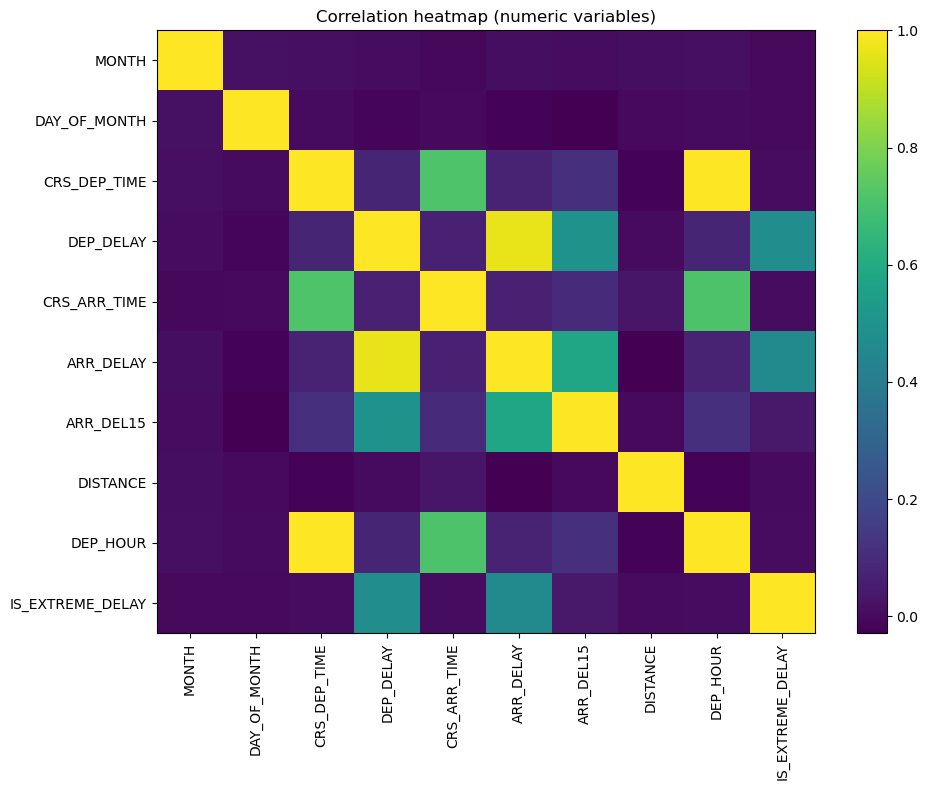

,MONTH,DAY_OF_MONTH,CRS_DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_DELAY,ARR_DEL15,DISTANCE,DEP_HOUR,IS_EXTREME_DELAY
MONTH,1.000000,0.017306,0.012831,0.005089,-0.007919,0.010081,0.004976,0.008605,0.012564,-0.000684
DAY_OF_MONTH,0.017306,1.000000,0.002356,-0.014772,-0.000694,-0.016933,-0.028784,-0.003885,0.002249,-0.002139
CRS_DEP_TIME,0.012831,0.002356,1.000000,0.076494,0.715314,0.073484,0.111162,-0.017954,0.999307,0.003840
DEP_DELAY,0.005089,-0.014772,0.076494,1.000000,0.065499,0.965891,0.498471,0.001449,0.076334,0.477221
CRS_ARR_TIME,-0.007919,-0.000694,0.715314,0.065499,1.000000,0.064511,0.098811,0.032876,0.714417,0.003902
ARR_DELAY,0.010081,-0.016933,0.073484,0.965891,0.064511,1.000000,0.574910,-0.026127,0.073329,0.460758
ARR_DEL15,0.004976,-0.028784,0.111162,0.498471,0.098811,0.574910,1.000000,-0.004199,0.110879,0.042484
DISTANCE,0.008605,-0.003885,-0.017954,0.001449,0.032876,-0.026127,-0.004199,1.000000,-0.018184,0.000753
DEP_HOUR,0.012564,0.002249,0.999307,0.076334,0.714417,0.073329,0.110879,-0.018184,1.000000,0.003824
IS_EXTREME_DELAY,-0.000684,-0.002139,0.003840,0.477221,0.003902,0.460758,0.042484,0.000753,0.003824,1.000000


In [49]:
numeric_cols = [
    "MONTH",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME",
    "DEP_DELAY",
    "CRS_ARR_TIME",
    "ARR_DELAY",
    "ARR_DEL15",
    "DISTANCE",
    "DEP_HOUR",
    "IS_EXTREME_DELAY",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation heatmap (numeric variables)")
plt.tight_layout()
plt.show()

corr


## 10b. Flight status by month: monthly trends

We plot **monthly disruption rates** (arrival delay ≥15 min, cancellations, diversions) as line charts. Q1 only contains three months, so this is a short-range seasonal snapshot rather than a long trend.

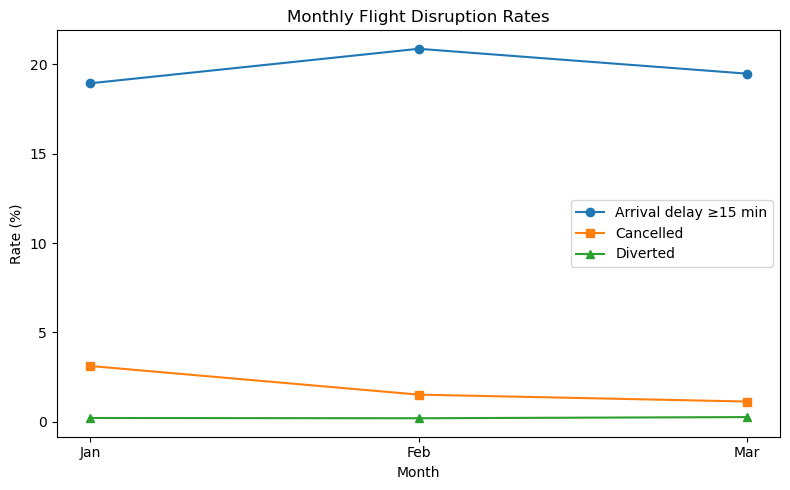

In [50]:
monthly_rates = (
    df.groupby("MONTH")
    .agg(
        delay_rate=("ARR_DEL15", "mean"),
        cancel_rate=("CANCELLED", "mean"),
        divert_rate=("DIVERTED", "mean"),
    )
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(monthly_rates.index, monthly_rates["delay_rate"] * 100, marker="o", label="Arrival delay ≥15 min")
plt.plot(monthly_rates.index, monthly_rates["cancel_rate"] * 100, marker="s", label="Cancelled")
plt.plot(monthly_rates.index, monthly_rates["divert_rate"] * 100, marker="^", label="Diverted")

plt.xticks([1, 2, 3], ["Jan", "Feb", "Mar"])
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.title("Monthly Flight Disruption Rates")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Unsupervised learning: airport-level K-means + PCA

Cluster **airports** (not 1.8M flights) using aggregated operational/delay profiles.

**Interpretation:** Features include delay outcomes (`delay_rate`, `avg_arr_delay`, …), so this is **profiling** airports by observed performance — not “schedule-only” clustering. If cluster IDs were ever used as model inputs, they must be fit without leakage (e.g. on training data only).

Airports with fewer than 100 originating flights are excluded from clustering (noisy rates).


In [51]:
airport_cluster = airport_summary[airport_summary["flight_count"] >= 100].copy()

cluster_features = [
    "delay_rate",
    "avg_arr_delay",
    "avg_dep_delay",
    "cancellation_rate",
    "diversion_rate",
    "avg_distance",
    "avg_dep_hour",
    "extreme_delay_rate",
]

X = airport_cluster[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Airports in clustering:", len(airport_cluster))


Airports in clustering: 337


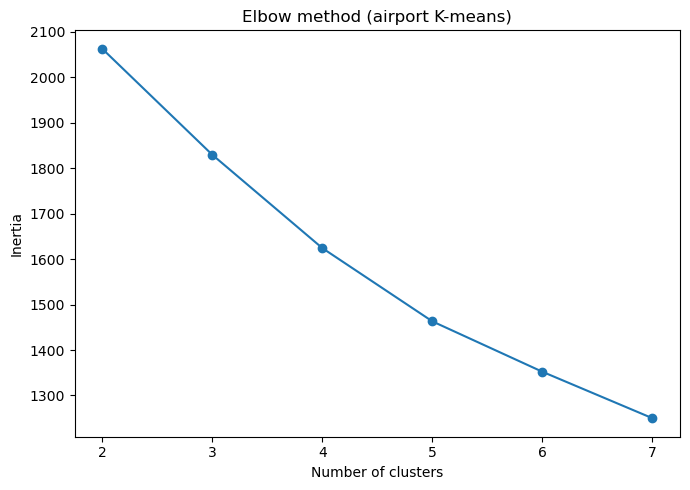

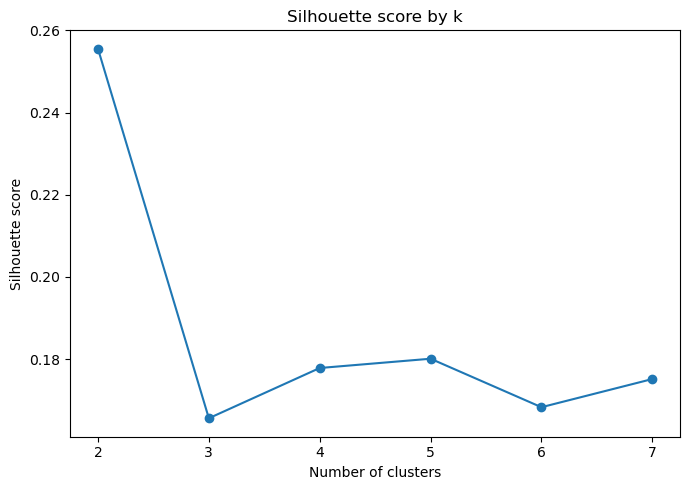

,k,inertia,silhouette_score
0,2,2062.551301,0.255537
1,3,1829.397704,0.165591
2,4,1624.092318,0.177823
3,5,1462.947823,0.180083
4,6,1352.072168,0.168279
5,7,1249.884467,0.175135


In [52]:
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method (airport K-means)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), sil_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(K_range), "inertia": inertias, "silhouette_score": sil_scores})


In [53]:
# Pick k from elbow / silhouette plots above (default 3).
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
airport_cluster["cluster"] = kmeans.fit_predict(X_scaled)

airport_cluster.head()


,ORIGIN_AIRPORT_ID,flight_count,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate,ORIGIN,cluster
0,10135,1150,0.193913,4.936522,9.166955,0.017842,0.005098,734.296517,11.686491,0.001699,ABE,0
1,10136,424,0.125000,-2.087264,4.312941,0.029748,0.000000,158.000000,10.871854,0.000000,ABI,0
2,10140,5613,0.132193,-0.774987,6.241600,0.011080,0.001759,630.003869,11.628737,0.000528,ABQ,0
3,10141,178,0.134831,9.494382,17.573034,0.005587,0.000000,257.000000,10.000000,0.000000,ABR,0
4,10146,239,0.150628,9.933054,18.179916,0.044000,0.000000,145.000000,11.436000,0.000000,ABY,1


In [54]:
cluster_means = airport_cluster.groupby("cluster")[cluster_features].mean().round(4)

cluster_sizes = airport_cluster.groupby("cluster").agg(
    n_airports=("ORIGIN_AIRPORT_ID", "count"),
    total_flights=("flight_count", "sum"),
    avg_flights_per_airport=("flight_count", "mean"),
).round(2)

cluster_profile = cluster_means.join(cluster_sizes)
cluster_profile


,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate,n_airports,total_flights,avg_flights_per_airport
cluster,,,,,,,,,,,
0,0.1693,2.9946,8.6461,0.0205,0.0023,585.2218,11.9942,0.0005,221,1646482,7450.14
1,0.2483,16.7016,20.2528,0.0348,0.0018,438.5934,11.7291,0.0023,116,136837,1179.63


In [55]:
airport_cluster["cluster"].value_counts().sort_index()


cluster
0    221
1    116
Name: count, dtype: int64

## 12. PCA visualization (two components, airports)


Explained variance ratio: [0.38120647 0.20463218]
Total explained variance: 0.5858386545052736


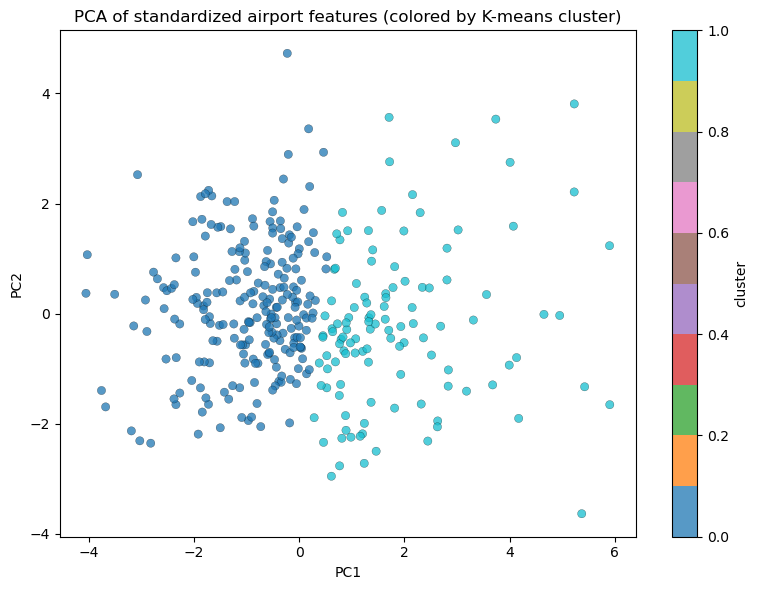

In [56]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

airport_cluster["PC1"] = X_pca[:, 0]
airport_cluster["PC2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", float(pca.explained_variance_ratio_.sum()))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    airport_cluster["PC1"],
    airport_cluster["PC2"],
    c=airport_cluster["cluster"],
    cmap="tab10",
    alpha=0.75,
    edgecolors="k",
    linewidths=0.2,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of standardized airport features (colored by K-means cluster)")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()


# Hierarchical clustering

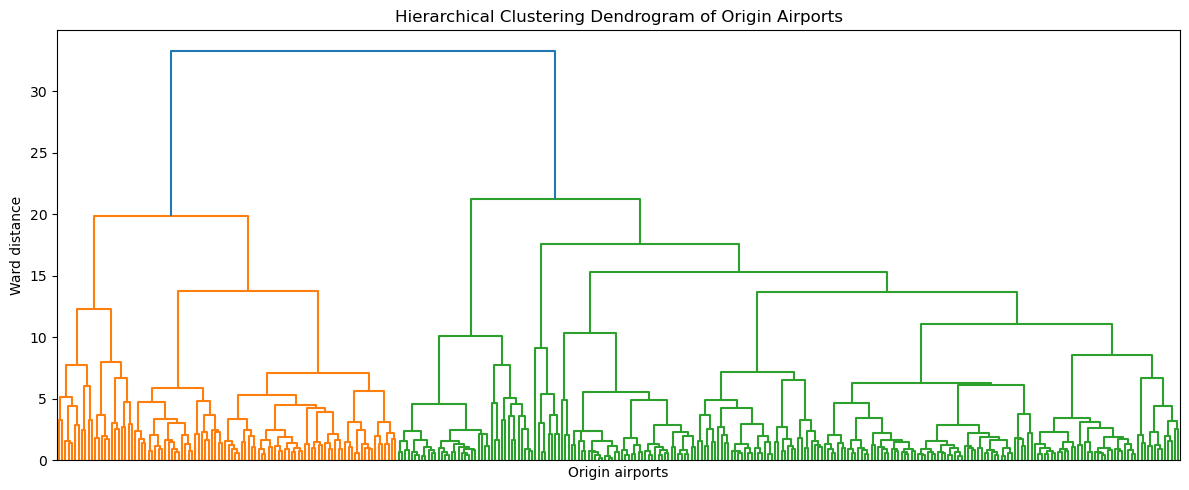

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Use the same standardized airport-level features
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram of Origin Airports")
plt.xlabel("Origin airports")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

For the unsupervised learning component, we clustered origin airports rather than individual flights. Each airport was represented by aggregated operational and delay features, including arrival delay rate, average arrival delay, average departure delay, cancellation rate, diversion rate, average route distance, average departure hour, and extreme delay rate. Airports with fewer than 100 flights were excluded to reduce noise from unstable rates. Since K-means is distance-based, all features were standardized before clustering.

We tested k values from 2 to 7 using the elbow method and silhouette score. The elbow plot did not show a sharp cutoff, but the silhouette score was highest at k = 2, so we selected a two-cluster solution. The cluster profile table shows that Cluster 0 represents relatively stable airports, with a lower delay rate, lower average arrival and departure delays, and a lower cancellation rate. Cluster 1 represents higher-delay and higher-disruption airports, with a delay rate of about 24.8%, compared with 16.9% for Cluster 0. The PCA visualization shows that these two airport groups are partially separated in the first two principal components, which explain about 58.6% of the variation in the standardized airport features. Finally, the hierarchical clustering dendrogram also shows two broad airport groups, supporting the two-cluster interpretation. Overall, the unsupervised analysis suggests that delay risk has meaningful airport-level structure.

The airport cluster label could be used as an engineered feature in later supervised models, because it summarizes airport-level delay risk. To avoid leakage, this clustering feature should be fitted only on the training set if used in model development.

## 13. Unsupervised learning: carrier-level profiles (K-means + PCA + hierarchy)

We aggregate flights to one row per carrier (OP_UNIQUE_CARRIER) using delay and disruption summaries (aligned with the airport-level analysis). There are only about twenty airlines, so cluster validity metrics can be noisy; we still report elbow and silhouette for transparency and choose k by the highest silhouette** among k ∈ {2, 3, 4, 5}**.



In [58]:
# One row per carrier
carrier_summary = (
    df.groupby("OP_UNIQUE_CARRIER")
    .agg(
        total_flights=("MONTH", "size"),
        completed_flights=("ARR_DEL15", "count"),
        delay_rate=("ARR_DEL15", "mean"),
        avg_arr_delay=("ARR_DELAY", "mean"),
        avg_dep_delay=("DEP_DELAY", "mean"),
        cancellation_rate=("CANCELLED", "mean"),
        diversion_rate=("DIVERTED", "mean"),
        avg_distance=("DISTANCE", "mean"),
        avg_dep_hour=("DEP_HOUR", "mean"),
        extreme_delay_rate=("IS_EXTREME_DELAY", "mean"),
    )
    .reset_index()
)

print("Carriers:", len(carrier_summary))
carrier_summary.sort_values("delay_rate", ascending=False)


Carriers: 21


,OP_UNIQUE_CARRIER,total_flights,completed_flights,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate
12,OH,62548,57658,0.286899,18.231798,21.092278,0.075494,0.002686,443.462940,13.131787,0.001727
20,ZW,10379,10183,0.265344,17.243150,18.378709,0.016957,0.001927,252.224492,12.973986,0.001542
8,G7,16648,16165,0.257346,15.062604,19.490679,0.027210,0.001802,369.242732,12.812230,0.000661
6,F9,49812,48752,0.254164,10.621472,15.335938,0.019353,0.001927,911.893098,13.400165,0.000662
3,B6,56907,55772,0.250807,8.587194,14.654374,0.016624,0.003321,1214.012020,13.075896,0.000369
7,G4,32071,31702,0.235096,10.560217,15.238259,0.008918,0.002588,950.298712,13.014156,0.001777
13,OO,195308,191241,0.213626,8.442813,12.857555,0.017521,0.003302,461.711118,13.001961,0.000456
1,AA,227500,221933,0.210595,7.902836,14.156822,0.021899,0.002571,994.887622,12.925815,0.001081
0,9E,55824,54490,0.194054,4.980455,9.926730,0.021926,0.001970,442.702655,13.015119,0.000340
10,MQ,65914,63738,0.193432,4.724026,8.318524,0.030813,0.002200,544.163562,12.949176,0.000212


In [59]:
carrier_features = [
    "delay_rate",
    "avg_arr_delay",
    "avg_dep_delay",
    "cancellation_rate",
    "diversion_rate",
    "avg_distance",
    "avg_dep_hour",
    "extreme_delay_rate",
]

X_carrier = carrier_summary[carrier_features].fillna(0)
scaler_carrier = StandardScaler()
X_carrier_scaled = scaler_carrier.fit_transform(X_carrier)


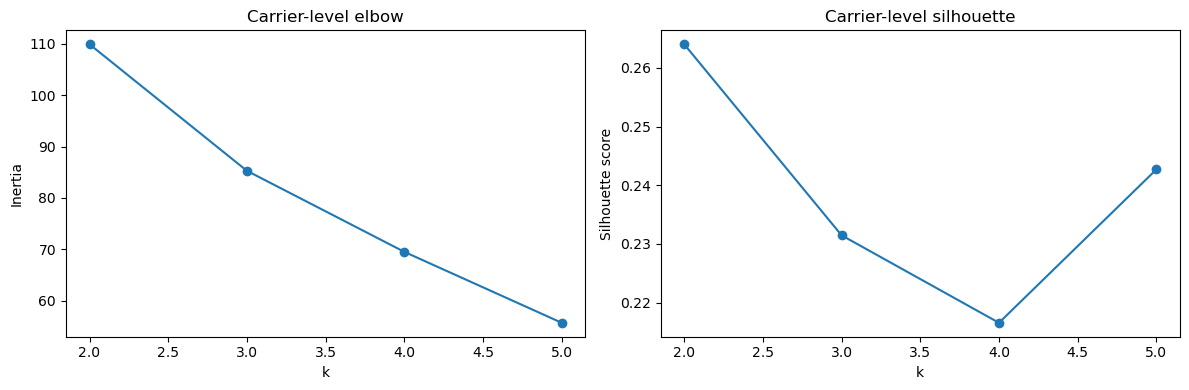

,k,inertia,silhouette
0,2,109.854720,0.264032
1,3,85.280233,0.231464
2,4,69.541538,0.216553
3,5,55.764135,0.242700


In [60]:
carrier_inertias = []
carrier_sil_scores = []
K_carrier_range = range(2, 6)

for k in K_carrier_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_carrier_scaled)
    carrier_inertias.append(km.inertia_)
    carrier_sil_scores.append(silhouette_score(X_carrier_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_carrier_range), carrier_inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Carrier-level elbow")

axes[1].plot(list(K_carrier_range), carrier_sil_scores, marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Carrier-level silhouette")

plt.tight_layout()
plt.show()

pd.DataFrame({
    "k": list(K_carrier_range),
    "inertia": carrier_inertias,
    "silhouette": carrier_sil_scores,
})


In [61]:
best_k_carrier = list(K_carrier_range)[int(np.argmax(carrier_sil_scores))]
print("Chosen k (max silhouette):", best_k_carrier)

carrier_kmeans = KMeans(n_clusters=best_k_carrier, random_state=42, n_init=10)
carrier_summary["carrier_cluster"] = carrier_kmeans.fit_predict(X_carrier_scaled)

carrier_summary.sort_values(["carrier_cluster", "delay_rate"])


Chosen k (max silhouette): 2


,OP_UNIQUE_CARRIER,total_flights,completed_flights,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate,carrier_cluster
14,PT,32837,32056,0.187859,5.953550,9.077738,0.020800,0.002984,299.240460,13.056065,0.001218,0
4,C5,19781,18955,0.190504,9.002005,13.553234,0.038522,0.003235,359.911582,12.826298,0.001112,0
1,AA,227500,221933,0.210595,7.902836,14.156822,0.021899,0.002571,994.887622,12.925815,0.001081,0
13,OO,195308,191241,0.213626,8.442813,12.857555,0.017521,0.003302,461.711118,13.001961,0.000456,0
7,G4,32071,31702,0.235096,10.560217,15.238259,0.008918,0.002588,950.298712,13.014156,0.001777,0
3,B6,56907,55772,0.250807,8.587194,14.654374,0.016624,0.003321,1214.012020,13.075896,0.000369,0
6,F9,49812,48752,0.254164,10.621472,15.335938,0.019353,0.001927,911.893098,13.400165,0.000662,0
8,G7,16648,16165,0.257346,15.062604,19.490679,0.027210,0.001802,369.242732,12.812230,0.000661,0
20,ZW,10379,10183,0.265344,17.243150,18.378709,0.016957,0.001927,252.224492,12.973986,0.001542,0
12,OH,62548,57658,0.286899,18.231798,21.092278,0.075494,0.002686,443.462940,13.131787,0.001727,0


In [62]:
carrier_cluster_profile = (
    carrier_summary.groupby("carrier_cluster")[
        carrier_features + ["total_flights", "completed_flights"]
    ]
    .mean()
    .round(4)
)

carrier_cluster_members = carrier_summary.groupby("carrier_cluster")[
    "OP_UNIQUE_CARRIER"
].apply(list)

print("Carriers per cluster:\n", carrier_cluster_members.to_string())
carrier_cluster_profile


Carriers per cluster:
 carrier_cluster
0        [AA, B6, C5, F9, G4, G7, OH, OO, PT, ZW]
1    [9E, AS, DL, HA, MQ, NK, QX, UA, WN, YV, YX]


,delay_rate,avg_arr_delay,avg_dep_delay,cancellation_rate,diversion_rate,avg_distance,avg_dep_hour,extreme_delay_rate,total_flights,completed_flights
carrier_cluster,,,,,,,,,,
0,0.2352,11.1608,15.3836,0.0263,0.0026,625.6885,13.0218,0.0011,70379.1000,68441.7000
1,0.1818,3.1661,8.3242,0.0190,0.0022,786.3412,12.9258,0.0002,101793.7273,99998.1818


Explained variance ratio: [0.49920806 0.14462644]
Total explained variance: 0.6438345020962535


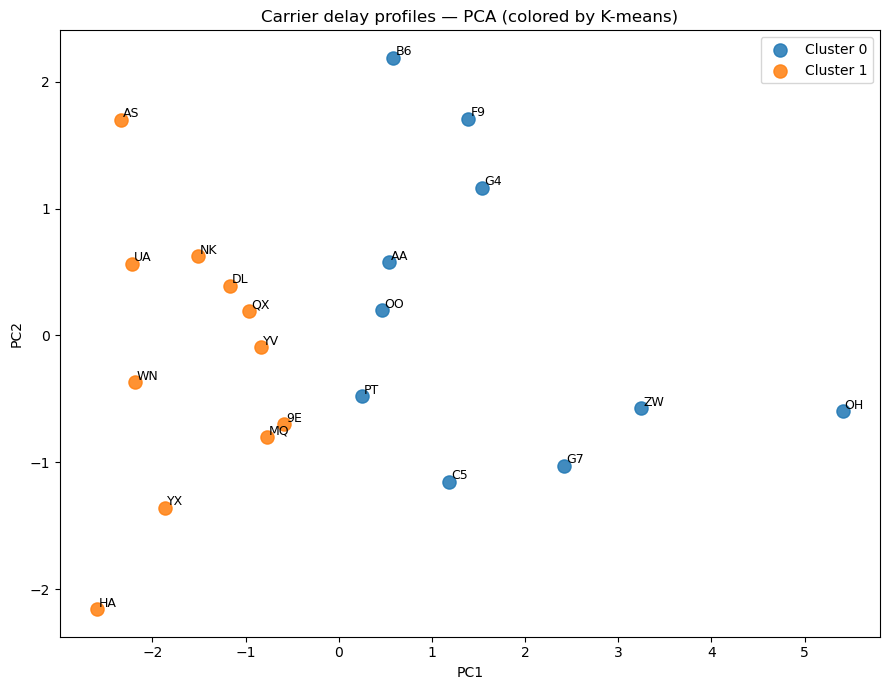

In [63]:
pca_carrier = PCA(n_components=2, random_state=42)
carrier_xy = pca_carrier.fit_transform(X_carrier_scaled)
carrier_summary["PC1"] = carrier_xy[:, 0]
carrier_summary["PC2"] = carrier_xy[:, 1]

print("Explained variance ratio:", pca_carrier.explained_variance_ratio_)
print("Total explained variance:", float(pca_carrier.explained_variance_ratio_.sum()))

plt.figure(figsize=(9, 7))
for cid in sorted(carrier_summary["carrier_cluster"].unique()):
    sub = carrier_summary[carrier_summary["carrier_cluster"] == cid]
    plt.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {cid}", s=90, alpha=0.85)

for _, row in carrier_summary.iterrows():
    plt.text(row["PC1"] + 0.02, row["PC2"] + 0.02, row["OP_UNIQUE_CARRIER"], fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Carrier delay profiles — PCA (colored by K-means)")
plt.legend()
plt.tight_layout()
plt.show()


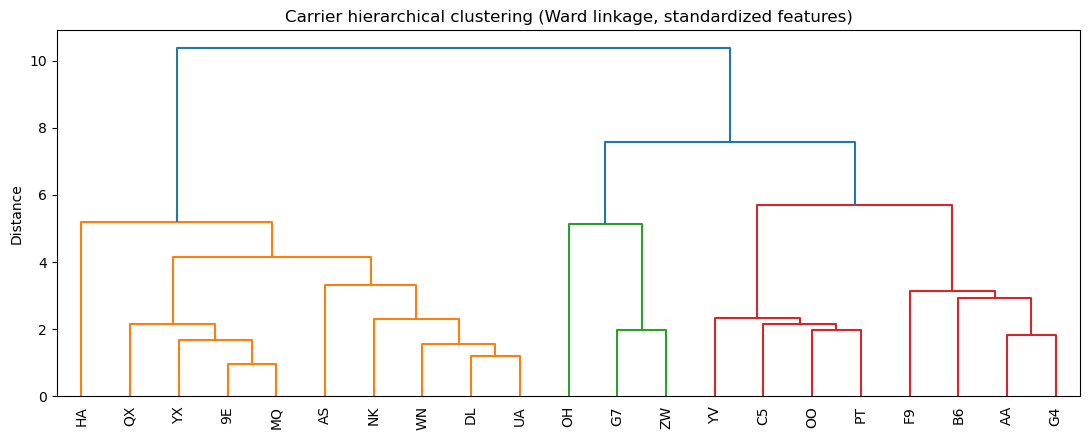

In [64]:
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(11, 4.5))
Zc = linkage(X_carrier_scaled, method="ward")
dendrogram(
    Zc,
    labels=carrier_summary["OP_UNIQUE_CARRIER"].astype(str).values,
    leaf_rotation=90,
)
plt.title("Carrier hierarchical clustering (Ward linkage, standardized features)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


As a supplementary unsupervised analysis, we also clustered carriers based on aggregated delay and operational features. Each carrier was represented by its arrival delay rate, average arrival delay, average departure delay, cancellation rate, diversion rate, average distance, average departure hour, and extreme delay rate. The silhouette score was highest at k = 2, although the score was modest, suggesting that the carrier groups should be interpreted as broad exploratory profiles rather than sharply separated categories. Cluster 0 had a higher delay rate, longer average arrival and departure delays, and a higher cancellation rate, while Cluster 1 showed a lower-delay and more stable profile. The PCA visualization explained about 64.4% of the variation in the first two components and showed a broad separation between the two groups.